# M22 · LLM-as-Judge & Validating the Judge — ✍️ Toy Examples, Step by Tiny Step

**Companion to lesson M22. Written for someone new to ML.**

An **LLM-as-judge** is a large language model used to **score** or **rank** model outputs.
In this notebook there is **no real LLM**: we simulate a judge with NumPy arrays so everything
runs offline in Colab or locally. The point is to learn the validation checklist:

1. Design a clear **rubric** (rules + score anchors).
2. Compare the judge with human **gold** scores.
3. Detect common biases: **position**, **verbosity**, and **self-preference**.
4. Correct the biases and check **calibration**.

Every idea has a **Toy example**, printed numbers, a picture, and an assert that pins the result.

## Step 0 · Setup

Import NumPy (arrays), pandas (tiny tables), scikit-learn/SciPy (metrics and calibration), and
Matplotlib (pictures). Fix the **random seed** so every run prints the same numbers.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.isotonic import IsotonicRegression

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)

def log(label, value):
    print(f"[{label}] {value}")

log("setup", "offline tools ready — NumPy, pandas, SciPy, scikit-learn, Matplotlib; seed=0")

[setup] offline tools ready — NumPy, pandas, SciPy, scikit-learn, Matplotlib; seed=0


---
# Part A · What is a judge, and what does it score?

## Step 1 · Toy example — What is LLM-as-judge?

**LLM-as-judge** means: use an LLM to **score** or **rank** model outputs against a rubric instead
of asking a human to score every item. It is useful for **scale, speed, and cost**, but the judge
can be wrong or biased. So the core rule is:

> Never trust a judge you have not validated against humans.

**Good for:** fast screening, regression tests, triage, and ranking many candidate answers.

**Watch out for:** the judge may reward the wrong thing, prefer one position, prefer long answers,
or favor outputs from its own model family.

[toy answers] ['too short', 'clear but missing a step', 'clear, complete, and correct']
[human scores on 1-5 scale] [2, 3, 5]
[simulated judge scores] [2.2, 3.4, 4.7]
[human winner] clear, complete, and correct
[judge winner] clear, complete, and correct


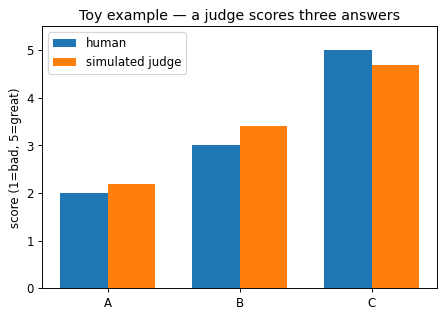

In [5]:
answers = np.array(["too short", "clear but missing a step", "clear, complete, and correct"])
human_scores = np.array([2, 3, 5])
simulated_judge_scores = np.array([2.2, 3.4, 4.7])  # a fake judge, not a real LLM

log("toy answers", answers.tolist())
log("human scores on 1-5 scale", human_scores.tolist())
log("simulated judge scores", simulated_judge_scores.tolist())
log("human winner", answers[int(human_scores.argmax())])
log("judge winner", answers[int(simulated_judge_scores.argmax())])

x = np.arange(len(answers))
plt.bar(x - 0.18, human_scores, width=0.36, label="human")
plt.bar(x + 0.18, simulated_judge_scores, width=0.36, label="simulated judge")
plt.xticks(x, ["A", "B", "C"])
plt.ylim(0, 5.5)
plt.ylabel("score (1=bad, 5=great)")
plt.title("Toy example — a judge scores three answers")
plt.legend()
plt.show()

## Step 1b · Toy example — Scoring versus ranking

A judge can output a **score** (for example 1–5) or a **rank/preference** (for example "C beats B").
Scores are easy to average; pairwise ranks are useful when absolute scores are hard.

[judge score order best→worst] ['clear, complete, and correct', 'clear but missing a step', 'too short']
[pairwise matrix entry[i,j]=1 means answer i beats answer j] [[0, 0, 0], [1, 0, 0], [1, 1, 0]]
[C beats B?] True


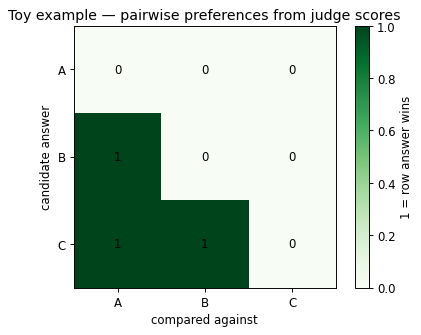

In [7]:
score_order = np.argsort(-simulated_judge_scores)
pairwise_pref = (simulated_judge_scores[:, None] > simulated_judge_scores[None, :]).astype(int)

log("judge score order best→worst", [answers[i] for i in score_order])
log("pairwise matrix entry[i,j]=1 means answer i beats answer j", pairwise_pref.tolist())
log("C beats B?", bool(pairwise_pref[2, 1]))

plt.imshow(pairwise_pref, cmap="Greens", vmin=0, vmax=1)
plt.xticks(range(3), ["A", "B", "C"]); plt.yticks(range(3), ["A", "B", "C"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, pairwise_pref[i, j], ha="center", va="center")
plt.title("Toy example — pairwise preferences from judge scores")
plt.xlabel("compared against"); plt.ylabel("candidate answer")
plt.colorbar(label="1 = row answer wins")
plt.show()

---
# Part B · Rubric design

## Step 2 · Toy example — A rubric with anchors

A **rubric** is a written scoring guide: it lists the criteria and the meaning of each score.
An **anchor** is a plain-English description of a score level. Good rubrics reduce scoring variance
because different raters are looking for the same evidence.

**Good for:** making scores repeatable, explainable, and easier to debug.

**Watch out for:** vague rubrics like "good answer" invite inconsistent scores.

[1-5 helpfulness rubric] 
 score                                         anchor
     1                                wrong or unsafe
     2          partly relevant but mostly incomplete
     3 basically helpful but misses an important step
     4              correct and clear with minor gaps
     5   correct, clear, complete, and well explained
[lowest anchor] wrong or unsafe
[highest anchor] correct, clear, complete, and well explained


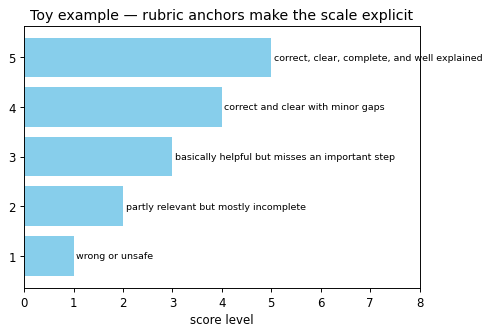

In [10]:
rubric = pd.DataFrame({
    "score": [1, 2, 3, 4, 5],
    "anchor": [
        "wrong or unsafe",
        "partly relevant but mostly incomplete",
        "basically helpful but misses an important step",
        "correct and clear with minor gaps",
        "correct, clear, complete, and well explained",
    ],
})

log("1-5 helpfulness rubric", "\n" + rubric.to_string(index=False))
log("lowest anchor", rubric.loc[0, "anchor"])
log("highest anchor", rubric.loc[4, "anchor"])

plt.barh(rubric["score"], rubric["score"], color="skyblue")
for _, row in rubric.iterrows():
    plt.text(row["score"] + 0.05, row["score"], row["anchor"], va="center", fontsize=8)
plt.xlim(0, 8)
plt.yticks(rubric["score"])
plt.xlabel("score level")
plt.title("Toy example — rubric anchors make the scale explicit")
plt.show()

## Step 2b · Toy example — Scoring with explicit criteria

A helpfulness rubric can be broken into criteria such as **correctness** (is it true?), **clarity**
(is it understandable?), and **completeness** (does it answer the whole question?).

[criterion table] 
                 answer  correctness  clarity  completeness  overall
               A: vague            2        2             1 1.666667
B: clear but incomplete            4        4             3 3.666667
            C: complete            5        5             5 5.000000
[overall scores] [1.67, 3.67, 5.0]
[best answer by rubric] C: complete


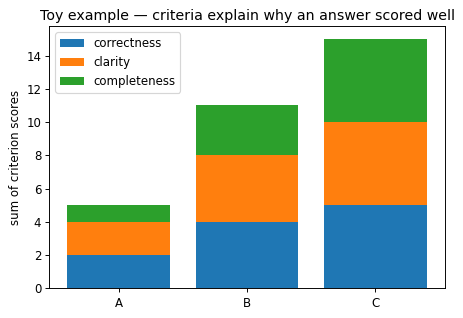

In [12]:
criterion_scores = pd.DataFrame({
    "answer": ["A: vague", "B: clear but incomplete", "C: complete"],
    "correctness": [2, 4, 5],
    "clarity": [2, 4, 5],
    "completeness": [1, 3, 5],
})
criterion_scores["overall"] = criterion_scores[["correctness", "clarity", "completeness"]].mean(axis=1)

log("criterion table", "\n" + criterion_scores.to_string(index=False))
log("overall scores", np.round(criterion_scores["overall"].values, 2).tolist())
log("best answer by rubric", criterion_scores.loc[criterion_scores["overall"].idxmax(), "answer"])

x = np.arange(len(criterion_scores))
bottom = np.zeros(len(criterion_scores))
for col in ["correctness", "clarity", "completeness"]:
    plt.bar(x, criterion_scores[col], bottom=bottom, label=col)
    bottom += criterion_scores[col].values
plt.xticks(x, ["A", "B", "C"])
plt.ylabel("sum of criterion scores")
plt.title("Toy example — criteria explain why an answer scored well")
plt.legend()
plt.show()

## Step 2c · Toy example — Anchors reduce rater variance

**Variance** means spread. If two people score the same item very differently, the variance is high.
A better rubric should make scores less spread out.

[scores without rubric (3 raters x 4 items)] [[2.0, 4.0, 5.0, 3.0], [1.0, 3.0, 5.0, 5.0], [3.0, 2.0, 4.0, 4.0]]
[scores with rubric] [[2.0, 3.0, 5.0, 4.0], [2.0, 3.0, 5.0, 4.0], [2.0, 4.0, 5.0, 4.0]]
[mean item variance without rubric] 0.556
[mean item variance with rubric] 0.056


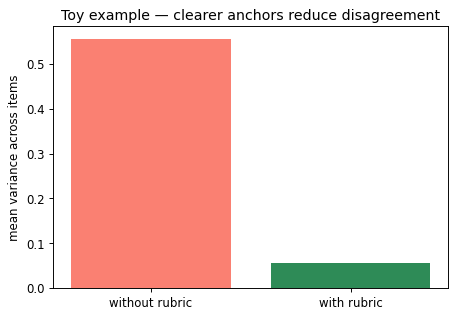

In [14]:
without_rubric = np.array([
    [2, 4, 5, 3],
    [1, 3, 5, 5],
    [3, 2, 4, 4],
], dtype=float)
with_rubric = np.array([
    [2, 3, 5, 4],
    [2, 3, 5, 4],
    [2, 4, 5, 4],
], dtype=float)

var_without = without_rubric.var(axis=0).mean()
var_with = with_rubric.var(axis=0).mean()
log("scores without rubric (3 raters x 4 items)", without_rubric.tolist())
log("scores with rubric", with_rubric.tolist())
log("mean item variance without rubric", round(float(var_without), 3))
log("mean item variance with rubric", round(float(var_with), 3))
assert var_with < var_without

plt.bar(["without rubric", "with rubric"], [var_without, var_with], color=["salmon", "seagreen"])
plt.ylabel("mean variance across items")
plt.title("Toy example — clearer anchors reduce disagreement")
plt.show()

---
# Part C · Measuring agreement with humans

## Step 3 · Toy example — Human-agreement measurement

**Inter-rater agreement** means "how much do two raters agree?" Here the two raters are a human
gold label and the simulated judge. **Correlation** measures whether two numeric lists move together
(high human scores should line up with high judge scores). **Cohen's kappa** measures categorical
agreement while subtracting agreement expected by chance:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

where \(p_o\) is observed agreement and \(p_e\) is chance agreement.

**Good for:** deciding whether a judge is close enough to humans for your use case.

**Watch out for:** a high correlation can hide bias; always inspect plots and categories too.

[first 8 human gold scores] [4.79, 3.56, 4.08, 5.0, 4.88, 2.32, 4.06, 3.06]
[first 8 judge scores] [4.06, 3.46, 3.68, 5.0, 4.65, 1.79, 4.04, 3.26]
[Pearson correlation (linear togetherness)] 0.937
[Spearman correlation (rank togetherness)] 0.925
[Cohen kappa on rounded 1-5 bins] 0.635


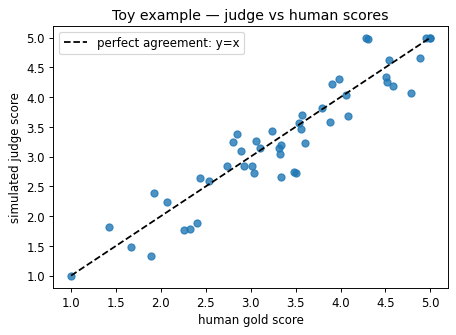

In [17]:
N = 48
human_gold = np.clip(np.random.normal(loc=3.2, scale=0.9, size=N), 1, 5)
judge_score = np.clip(human_gold + np.random.normal(loc=0.0, scale=0.45, size=N), 1, 5)

pearson_r = float(np.corrcoef(human_gold, judge_score)[0, 1])
spearman_r = float(spearmanr(human_gold, judge_score)[0])
human_bins = np.rint(human_gold).astype(int)
judge_bins = np.rint(judge_score).astype(int)
kappa = float(cohen_kappa_score(human_bins, judge_bins))

log("first 8 human gold scores", np.round(human_gold[:8], 2).tolist())
log("first 8 judge scores", np.round(judge_score[:8], 2).tolist())
log("Pearson correlation (linear togetherness)", round(pearson_r, 3))
log("Spearman correlation (rank togetherness)", round(spearman_r, 3))
log("Cohen kappa on rounded 1-5 bins", round(kappa, 3))
assert -1 <= kappa <= 1

plt.scatter(human_gold, judge_score, alpha=0.8)
plt.plot([1, 5], [1, 5], "k--", label="perfect agreement: y=x")
plt.xlabel("human gold score")
plt.ylabel("simulated judge score")
plt.title("Toy example — judge vs human scores")
plt.legend()
plt.show()

## Step 3b · Toy example — Kappa sees category mistakes

Rounding scores into categories lets us ask: did the judge choose the **same bucket** as the human?
A confusion matrix shows where the mistakes are.

[human bins first 12] [5, 4, 4, 5, 5, 2, 4, 3, 3, 4, 3, 5]
[judge bins first 12] [4, 3, 4, 5, 5, 2, 4, 3, 3, 4, 3, 4]
[exact categorical agreement] 0.729
[confusion matrix rows=human, cols=judge] [[1, 1, 0, 0, 0], [2, 5, 1, 0, 0], [0, 0, 16, 0, 0], [0, 0, 3, 8, 2], [0, 0, 0, 4, 5]]
[Cohen kappa again] 0.635


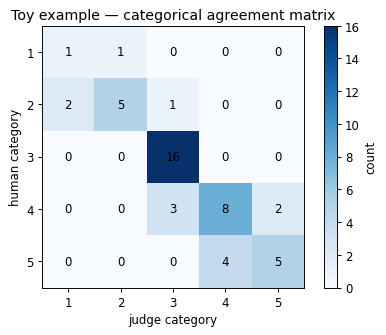

In [19]:
labels = [1, 2, 3, 4, 5]
conf = confusion_matrix(human_bins, judge_bins, labels=labels)
exact_agree = float(np.mean(human_bins == judge_bins))

log("human bins first 12", human_bins[:12].tolist())
log("judge bins first 12", judge_bins[:12].tolist())
log("exact categorical agreement", round(exact_agree, 3))
log("confusion matrix rows=human, cols=judge", conf.tolist())
log("Cohen kappa again", round(kappa, 3))
assert -1 <= kappa <= 1

plt.imshow(conf, cmap="Blues")
plt.xticks(range(5), labels); plt.yticks(range(5), labels)
for i in range(5):
    for j in range(5):
        plt.text(j, i, conf[i, j], ha="center", va="center")
plt.xlabel("judge category")
plt.ylabel("human category")
plt.title("Toy example — categorical agreement matrix")
plt.colorbar(label="count")
plt.show()

## Step 3c · Toy example — Pairwise-preference accuracy

**Pairwise-preference accuracy** asks: given two answers, did the judge pick the same winner as the
human? This is often easier than agreeing on an exact 1–5 score.

[first 6 human left-right margins] [-0.21, 1.67, 0.84, 1.97, 0.3, -2.2]
[first 6 judge left-right margins] [-0.94, 2.13, 0.26, 2.28, 0.46, -2.47]
[judge agrees with human winner count] 21
[pairwise-preference accuracy] 0.875


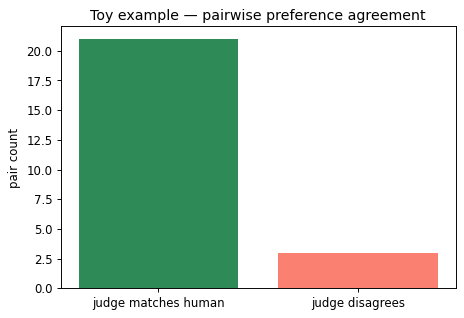

In [21]:
left = np.arange(0, N // 2)
right = np.arange(N // 2, N)
human_pref_left = human_gold[left] >= human_gold[right]
judge_pref_left = judge_score[left] >= judge_score[right]
pairwise_accuracy = float(np.mean(human_pref_left == judge_pref_left))

log("first 6 human left-right margins", np.round((human_gold[left] - human_gold[right])[:6], 2).tolist())
log("first 6 judge left-right margins", np.round((judge_score[left] - judge_score[right])[:6], 2).tolist())
log("judge agrees with human winner count", int((human_pref_left == judge_pref_left).sum()))
log("pairwise-preference accuracy", round(pairwise_accuracy, 3))
assert pairwise_accuracy >= 0.65

plt.bar(["judge matches human", "judge disagrees"], [
    int((human_pref_left == judge_pref_left).sum()),
    int((human_pref_left != judge_pref_left).sum())
], color=["seagreen", "salmon"])
plt.ylabel("pair count")
plt.title("Toy example — pairwise preference agreement")
plt.show()

---
# Part D · Bias check 1: position bias

## Step 4 · Toy example — POSITION bias

**Position bias** means a pairwise judge tends to prefer whichever answer is shown **first**, even
when answer quality is the same. To test it, judge the same pair twice: order `(A, B)` and order
`(B, A)`.

**Good for:** finding UI/order artifacts in pairwise evaluation.

**Watch out for:** one-order tests can make a biased judge look confident.

[position bonus added to first answer] 0.65
[first wins in AB order] 0.838
[first wins in BA order] 0.762
[overall first-position win rate] 0.8
[position-swap flip rate] 0.6


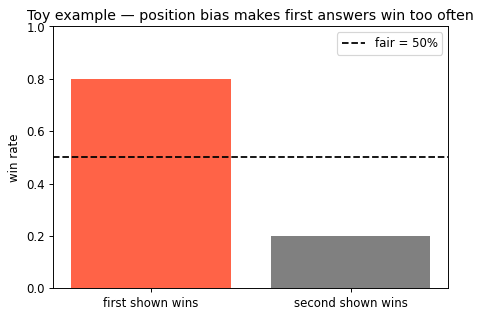

In [24]:
M = 80
quality_A = np.random.normal(0, 1, M)
quality_B = quality_A + np.random.normal(0, 0.9, M)
true_margin_A = quality_A - quality_B
position_bonus = 0.65

judge_margin_AB = true_margin_A + position_bonus       # A is first
judge_margin_BA_as_A = true_margin_A - position_bonus  # B is first, so A loses the bonus
judge_A_wins_AB = judge_margin_AB > 0
judge_A_wins_BA = judge_margin_BA_as_A > 0
first_wins_AB = judge_A_wins_AB
first_wins_BA = ~judge_A_wins_BA
first_win_rate = float(np.mean(np.r_[first_wins_AB, first_wins_BA]))
swap_flip_rate = float(np.mean(judge_A_wins_AB != judge_A_wins_BA))

log("position bonus added to first answer", position_bonus)
log("first wins in AB order", round(float(np.mean(first_wins_AB)), 3))
log("first wins in BA order", round(float(np.mean(first_wins_BA)), 3))
log("overall first-position win rate", round(first_win_rate, 3))
log("position-swap flip rate", round(swap_flip_rate, 3))
assert 0 <= swap_flip_rate <= 1
assert first_win_rate > 0.60 and swap_flip_rate > 0.25

plt.bar(["first shown wins", "second shown wins"], [first_win_rate, 1 - first_win_rate],
        color=["tomato", "gray"])
plt.axhline(0.5, color="black", linestyle="--", label="fair = 50%")
plt.ylim(0, 1)
plt.ylabel("win rate")
plt.title("Toy example — position bias makes first answers win too often")
plt.legend()
plt.show()

## Step 4b · Toy example — Correct by swapping and averaging

If you evaluate both orders and average the two judge margins, the position bonus cancels out:
first in `(A, B)` gives A a bonus; first in `(B, A)` gives B the same bonus.

[raw AB accuracy] 0.738
[raw BA accuracy] 0.662
[swap-and-average accuracy] 1.0
[remaining position effect after averaging] 0.0


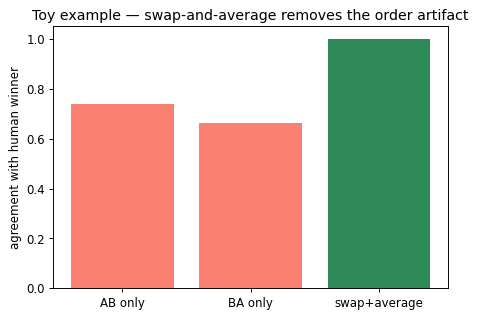

In [26]:
human_A_wins = true_margin_A > 0
raw_AB_accuracy = float(np.mean(judge_A_wins_AB == human_A_wins))
raw_BA_accuracy = float(np.mean(judge_A_wins_BA == human_A_wins))
avg_margin_A = (judge_margin_AB + judge_margin_BA_as_A) / 2
debiased_A_wins = avg_margin_A > 0
debiased_accuracy = float(np.mean(debiased_A_wins == human_A_wins))
remaining_position_effect = float(abs(np.mean(debiased_A_wins) - np.mean(human_A_wins)))

log("raw AB accuracy", round(raw_AB_accuracy, 3))
log("raw BA accuracy", round(raw_BA_accuracy, 3))
log("swap-and-average accuracy", round(debiased_accuracy, 3))
log("remaining position effect after averaging", round(remaining_position_effect, 3))
assert debiased_accuracy >= max(raw_AB_accuracy, raw_BA_accuracy)

plt.bar(["AB only", "BA only", "swap+average"], [raw_AB_accuracy, raw_BA_accuracy, debiased_accuracy],
        color=["salmon", "salmon", "seagreen"])
plt.ylim(0, 1.05)
plt.ylabel("agreement with human winner")
plt.title("Toy example — swap-and-average removes the order artifact")
plt.show()

## Step 4c · Toy example — Randomization balances exposure

Swapping is best for measurement. When you cannot judge both orders, randomize the order so one model
does not always appear first.

[A shown first fraction under randomization] 0.562
[B shown first fraction under randomization] 0.438
[first still wins too often if judge is biased] 0.825
[why randomize?] it spreads that bias across systems instead of giving it all to one side


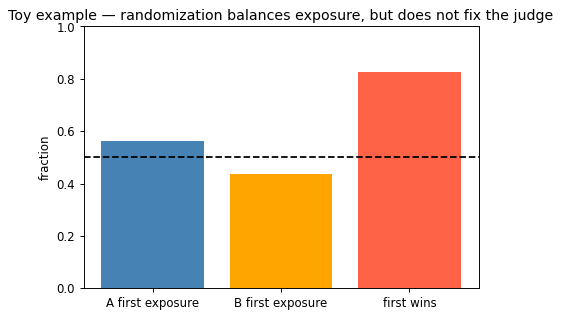

In [28]:
random_first_is_A = np.random.rand(M) < 0.5
exposure_A_first = float(np.mean(random_first_is_A))
exposure_B_first = 1 - exposure_A_first
observed_first_wins = np.where(random_first_is_A, first_wins_AB, first_wins_BA)
observed_first_win_rate = float(np.mean(observed_first_wins))

log("A shown first fraction under randomization", round(exposure_A_first, 3))
log("B shown first fraction under randomization", round(exposure_B_first, 3))
log("first still wins too often if judge is biased", round(observed_first_win_rate, 3))
log("why randomize?", "it spreads that bias across systems instead of giving it all to one side")
assert abs(exposure_A_first - 0.5) < 0.15

plt.bar(["A first exposure", "B first exposure", "first wins"], [
    exposure_A_first, exposure_B_first, observed_first_win_rate
], color=["steelblue", "orange", "tomato"])
plt.axhline(0.5, color="black", linestyle="--")
plt.ylim(0, 1)
plt.ylabel("fraction")
plt.title("Toy example — randomization balances exposure, but does not fix the judge")
plt.show()

---
# Part E · Bias check 2: verbosity bias

## Step 5 · Toy example — VERBOSITY bias

**Verbosity bias** means the judge gives **longer** answers higher scores even when length is not
the same as quality. We simulate true quality and answer length separately, then add a length bump
to the judge.

**Good for:** catching judges that reward word count instead of usefulness.

**Watch out for:** a long answer can be good, but length should not be a shortcut for quality.

[first 8 answer lengths] [102, 116, 87, 116, 189, 160, 58, 129]
[first 8 true quality scores] [3.39, 2.58, 2.39, 2.98, 3.09, 4.78, 2.71, 3.86]
[first 8 judge scores with length bump] [2.41, 2.66, 1.75, 2.43, 3.64, 4.75, 1.43, 3.75]
[length-vs-judge-score correlation] 0.673


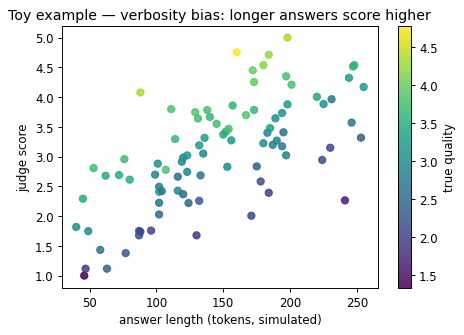

In [31]:
V = 90
true_quality_v = np.clip(np.random.normal(3.2, 0.7, V), 1, 5)
answer_length = np.random.randint(40, 260, V)
length_centered = answer_length - answer_length.mean()
judge_verbose = np.clip(true_quality_v + 0.010 * length_centered + np.random.normal(0, 0.20, V), 1, 5)
length_score_corr = float(np.corrcoef(answer_length, judge_verbose)[0, 1])

log("first 8 answer lengths", answer_length[:8].tolist())
log("first 8 true quality scores", np.round(true_quality_v[:8], 2).tolist())
log("first 8 judge scores with length bump", np.round(judge_verbose[:8], 2).tolist())
log("length-vs-judge-score correlation", round(length_score_corr, 3))
assert length_score_corr > 0.55

plt.scatter(answer_length, judge_verbose, c=true_quality_v, cmap="viridis", alpha=0.85)
plt.xlabel("answer length (tokens, simulated)")
plt.ylabel("judge score")
plt.title("Toy example — verbosity bias: longer answers score higher")
plt.colorbar(label="true quality")
plt.show()

## Step 5b · Toy example — Correct verbosity bias by regressing out length

To **control for** length means "remove the part of the score explained by length." A simple way is
linear regression: estimate the length slope, subtract it, then keep the average score level.

[estimated length slope (score per token)] 0.0109
[length-score correlation before correction] 0.673
[length-score correlation after correction] 0.0
[true-quality correlation before] 0.754
[true-quality correlation after] 0.945


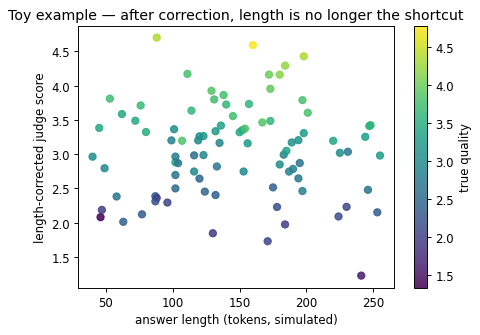

In [33]:
slope, intercept = np.polyfit(answer_length, judge_verbose, 1)
judge_length_corrected = judge_verbose - slope * (answer_length - answer_length.mean())
corr_after_length_control = float(np.corrcoef(answer_length, judge_length_corrected)[0, 1])
quality_corr_before = float(np.corrcoef(true_quality_v, judge_verbose)[0, 1])
quality_corr_after = float(np.corrcoef(true_quality_v, judge_length_corrected)[0, 1])

log("estimated length slope (score per token)", round(float(slope), 4))
log("length-score correlation before correction", round(length_score_corr, 3))
log("length-score correlation after correction", round(corr_after_length_control, 3))
log("true-quality correlation before", round(quality_corr_before, 3))
log("true-quality correlation after", round(quality_corr_after, 3))
assert abs(corr_after_length_control) < abs(length_score_corr) * 0.35

plt.scatter(answer_length, judge_length_corrected, c=true_quality_v, cmap="viridis", alpha=0.85)
plt.xlabel("answer length (tokens, simulated)")
plt.ylabel("length-corrected judge score")
plt.title("Toy example — after correction, length is no longer the shortcut")
plt.colorbar(label="true quality")
plt.show()

## Step 5c · Toy example — Compare short, medium, and long buckets

Another beginner-friendly check is to bucket answers by length and compare mean scores before and
after correction.

[bucket means] 
        raw_judge  corrected_judge  true_quality
bucket                                          
short       2.071            2.900         2.834
medium      3.104            3.193         3.203
long        3.686            2.956         3.017
[long-short raw score gap] 1.615
[long-short corrected score gap] 0.056


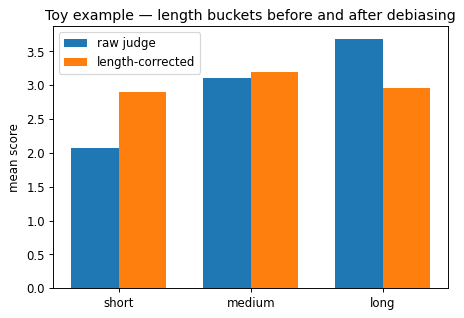

In [35]:
length_bucket = pd.cut(answer_length, bins=[0, 100, 180, 300], labels=["short", "medium", "long"])
verbosity_table = pd.DataFrame({
    "bucket": length_bucket,
    "raw_judge": judge_verbose,
    "corrected_judge": judge_length_corrected,
    "true_quality": true_quality_v,
})
bucket_means = verbosity_table.groupby("bucket", observed=False).mean(numeric_only=True)
raw_gap = float(bucket_means.loc["long", "raw_judge"] - bucket_means.loc["short", "raw_judge"])
corrected_gap = float(bucket_means.loc["long", "corrected_judge"] - bucket_means.loc["short", "corrected_judge"])

log("bucket means", "\n" + bucket_means.round(3).to_string())
log("long-short raw score gap", round(raw_gap, 3))
log("long-short corrected score gap", round(corrected_gap, 3))
assert abs(corrected_gap) < abs(raw_gap)

x = np.arange(len(bucket_means))
plt.bar(x - 0.18, bucket_means["raw_judge"], width=0.36, label="raw judge")
plt.bar(x + 0.18, bucket_means["corrected_judge"], width=0.36, label="length-corrected")
plt.xticks(x, bucket_means.index)
plt.ylabel("mean score")
plt.title("Toy example — length buckets before and after debiasing")
plt.legend()
plt.show()

---
# Part F · Bias check 3: self-preference bias

## Step 6 · Toy example — SELF-PREFERENCE bias

**Self-preference bias** means a judge gives higher scores to outputs from its **own model family**
even when true quality is the same. We simulate three source families with equal true quality, then
give the judge's own family a bump.

**Good for:** checking whether a judge unfairly favors one vendor/model family.

**Watch out for:** model names, writing style, or hidden metadata can leak the source family.

[mean true quality by family] 
family
JudgeFamily    3.342
OtherA         3.444
OtherB         3.444
[mean biased judge score by family] 
family
JudgeFamily    3.916
OtherA         3.446
OtherB         3.435
[own-family score inflation] 0.476


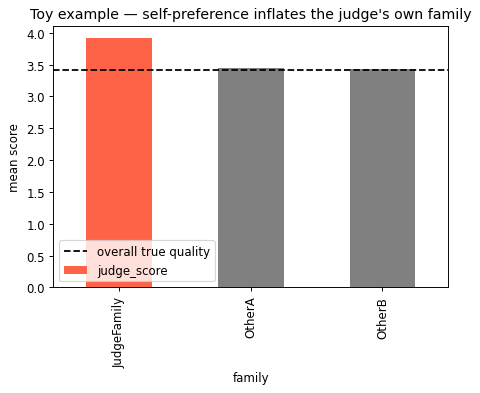

In [38]:
families = np.array(["JudgeFamily"] * 30 + ["OtherA"] * 30 + ["OtherB"] * 30)
base_quality_self = np.r_[np.random.normal(3.4, 0.25, 30),
                          np.random.normal(3.4, 0.25, 30),
                          np.random.normal(3.4, 0.25, 30)]
own_family_bump = (families == "JudgeFamily") * 0.55
biased_family_score = np.clip(base_quality_self + own_family_bump + np.random.normal(0, 0.15, len(families)), 1, 5)
self_df = pd.DataFrame({"family": families, "true_quality": base_quality_self, "judge_score": biased_family_score})
family_means = self_df.groupby("family").mean(numeric_only=True)
own_gap = float(family_means.loc["JudgeFamily", "judge_score"] -
                family_means.loc[["OtherA", "OtherB"], "judge_score"].mean())

log("mean true quality by family", "\n" + family_means["true_quality"].round(3).to_string())
log("mean biased judge score by family", "\n" + family_means["judge_score"].round(3).to_string())
log("own-family score inflation", round(own_gap, 3))
assert own_gap > 0.35

family_means["judge_score"].plot(kind="bar", color=["tomato", "gray", "gray"])
plt.axhline(family_means["true_quality"].mean(), color="black", linestyle="--", label="overall true quality")
plt.ylabel("mean score")
plt.title("Toy example — self-preference inflates the judge's own family")
plt.legend()
plt.show()

## Step 6b · Toy example — Mitigate with an independent judge

An **independent judge** is a judge from a different model family or evaluation process. If the bump
was self-preference, the own-family gap should shrink with an independent judge.

[biased own-family gap] 0.476
[independent judge own-family gap] -0.101
[gap reduction] 0.576


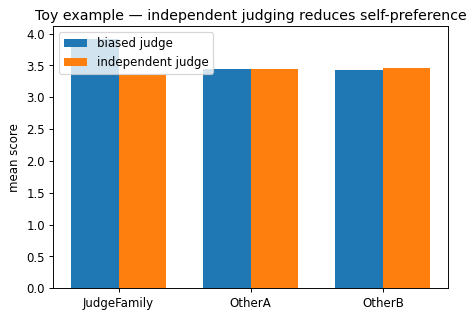

In [40]:
independent_score = np.clip(base_quality_self + np.random.normal(0, 0.18, len(families)), 1, 5)
self_df["independent_score"] = independent_score
independent_means = self_df.groupby("family").mean(numeric_only=True)
independent_gap = float(independent_means.loc["JudgeFamily", "independent_score"] -
                        independent_means.loc[["OtherA", "OtherB"], "independent_score"].mean())

log("biased own-family gap", round(own_gap, 3))
log("independent judge own-family gap", round(independent_gap, 3))
log("gap reduction", round(own_gap - independent_gap, 3))
assert abs(independent_gap) < abs(own_gap)

x = np.arange(3)
plt.bar(x - 0.18, independent_means["judge_score"], width=0.36, label="biased judge")
plt.bar(x + 0.18, independent_means["independent_score"], width=0.36, label="independent judge")
plt.xticks(x, independent_means.index)
plt.ylabel("mean score")
plt.title("Toy example — independent judging reduces self-preference")
plt.legend()
plt.show()

## Step 6c · Toy example — Ensemble judges reduce one judge's preference

An **ensemble** averages multiple judges. It does not magically prove truth, but it can reduce the
effect of one judge's special preference.

[biased judge gap] 0.476
[ensemble gap] 0.098
[why still not zero?] the biased judge is still one member of the ensemble


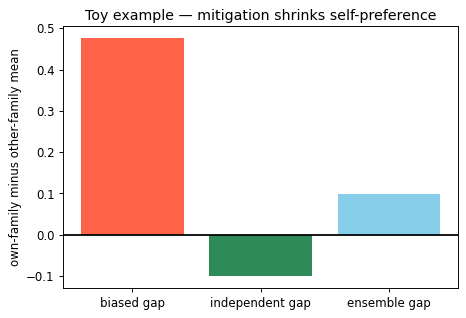

In [42]:
second_independent = np.clip(base_quality_self + np.random.normal(0, 0.18, len(families)), 1, 5)
ensemble_score = (biased_family_score + independent_score + second_independent) / 3
self_df["ensemble_score"] = ensemble_score
ensemble_means = self_df.groupby("family").mean(numeric_only=True)
ensemble_gap = float(ensemble_means.loc["JudgeFamily", "ensemble_score"] -
                     ensemble_means.loc[["OtherA", "OtherB"], "ensemble_score"].mean())

log("biased judge gap", round(own_gap, 3))
log("ensemble gap", round(ensemble_gap, 3))
log("why still not zero?", "the biased judge is still one member of the ensemble")
assert abs(ensemble_gap) < abs(own_gap)

plt.bar(["biased gap", "independent gap", "ensemble gap"], [own_gap, independent_gap, ensemble_gap],
        color=["tomato", "seagreen", "skyblue"])
plt.axhline(0, color="black")
plt.ylabel("own-family minus other-family mean")
plt.title("Toy example — mitigation shrinks self-preference")
plt.show()

---
# Part G · Judge calibration

## Step 7 · Toy example — CALIBRATION

**Calibration** asks: when the judge says "4.0", is the true human quality also about 4.0?
A **calibration curve** bins judge scores and compares each bin's average judge score with average
true quality.

**Good for:** turning judge scores into trustworthy thresholds, dashboards, and release gates.

**Watch out for:** a judge can rank items well but still be miscalibrated (for example, always too high).

[first 8 true qualities] [3.46, 2.82, 3.22, 2.14, 2.74, 2.92, 3.1, 2.84]
[first 8 raw judge scores] [4.24, 3.52, 4.24, 2.74, 3.63, 4.11, 3.53, 3.82]
[raw calibration points (mean judge, mean true, count)] [(1.48, 1.0, 1), (2.15, 1.5, 8), (2.94, 2.23, 30), (3.78, 2.98, 34), (4.74, 3.8, 47)]
[raw calibration error] 0.822


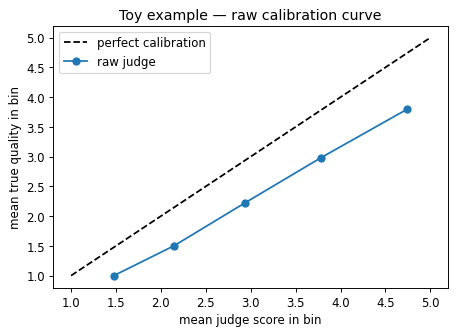

In [45]:
C = 120
true_cal = np.clip(np.random.normal(3.0, 0.9, C), 1, 5)
raw_cal_judge = np.clip(0.35 + 1.18 * true_cal + np.random.normal(0, 0.22, C), 1, 5)

def calibration_points(scores, truth, bins=np.linspace(1, 5, 6)):
    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        if hi == bins[-1]:
            mask = (scores >= lo) & (scores <= hi)
        else:
            mask = (scores >= lo) & (scores < hi)
        if mask.any():
            rows.append((float(scores[mask].mean()), float(truth[mask].mean()), int(mask.sum())))
    return rows

def calibration_error(scores, truth):
    pts = calibration_points(scores, truth)
    total = sum(n for _, _, n in pts)
    return sum(n * abs(mean_score - mean_truth) for mean_score, mean_truth, n in pts) / total

raw_calibration_points = calibration_points(raw_cal_judge, true_cal)
raw_calibration_error = float(calibration_error(raw_cal_judge, true_cal))

log("first 8 true qualities", np.round(true_cal[:8], 2).tolist())
log("first 8 raw judge scores", np.round(raw_cal_judge[:8], 2).tolist())
log("raw calibration points (mean judge, mean true, count)", [(round(a, 2), round(b, 2), n) for a, b, n in raw_calibration_points])
log("raw calibration error", round(raw_calibration_error, 3))

xs = [p[0] for p in raw_calibration_points]
ys = [p[1] for p in raw_calibration_points]
plt.plot([1, 5], [1, 5], "k--", label="perfect calibration")
plt.plot(xs, ys, "-o", label="raw judge")
plt.xlabel("mean judge score in bin")
plt.ylabel("mean true quality in bin")
plt.title("Toy example — raw calibration curve")
plt.legend()
plt.show()

## Step 7b · Toy example — Correct calibration with a learned mapping

We fit a simple monotonic mapping from raw judge score to human quality using **isotonic regression**.
Monotonic means higher raw scores still map to higher calibrated scores.

[raw calibration error] 0.822
[calibrated error] 0.0
[error drop] 0.822
[calibrated points (mean calibrated, mean true, count)] [(1.39, 1.39, 8), (2.19, 2.19, 29), (3.03, 3.03, 49), (4.01, 4.01, 34)]


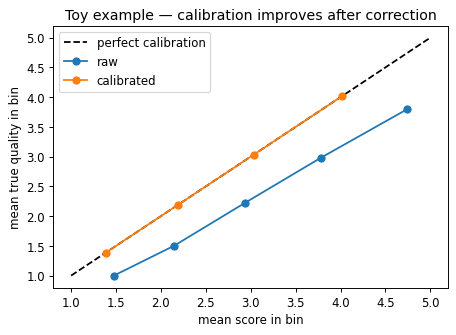

In [47]:
iso = IsotonicRegression(out_of_bounds="clip")
calibrated_score = iso.fit_transform(raw_cal_judge, true_cal)
calibrated_error = float(calibration_error(calibrated_score, true_cal))
calibrated_points = calibration_points(calibrated_score, true_cal)

log("raw calibration error", round(raw_calibration_error, 3))
log("calibrated error", round(calibrated_error, 3))
log("error drop", round(raw_calibration_error - calibrated_error, 3))
log("calibrated points (mean calibrated, mean true, count)", [(round(a, 2), round(b, 2), n) for a, b, n in calibrated_points])
assert calibrated_error < raw_calibration_error

plt.plot([1, 5], [1, 5], "k--", label="perfect calibration")
plt.plot([p[0] for p in raw_calibration_points], [p[1] for p in raw_calibration_points], "-o", label="raw")
plt.plot([p[0] for p in calibrated_points], [p[1] for p in calibrated_points], "-o", label="calibrated")
plt.xlabel("mean score in bin")
plt.ylabel("mean true quality in bin")
plt.title("Toy example — calibration improves after correction")
plt.legend()
plt.show()

## Step 7c · Toy example — Calibration changes decisions at a threshold

If a launch rule says "ship only answers with score ≥ 4", a miscalibrated judge may ship too many
or too few items. Calibrated scores make the threshold closer to human meaning.

[raw score ships count] 55
[calibrated score ships count] 21
[true high-quality count] 12
[precision among shipped items — raw] 0.218
[precision among shipped items — calibrated] 0.524


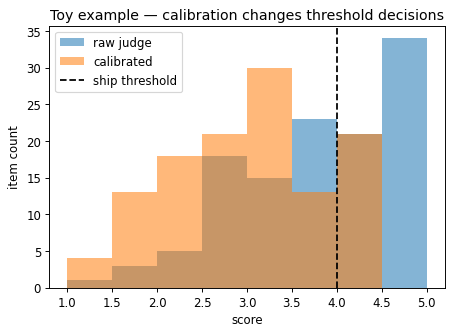

In [49]:
raw_ship = raw_cal_judge >= 4.0
calibrated_ship = calibrated_score >= 4.0
true_high_quality = true_cal >= 4.0
raw_precision = float(np.mean(true_high_quality[raw_ship])) if raw_ship.any() else 0.0
cal_precision = float(np.mean(true_high_quality[calibrated_ship])) if calibrated_ship.any() else 0.0

log("raw score ships count", int(raw_ship.sum()))
log("calibrated score ships count", int(calibrated_ship.sum()))
log("true high-quality count", int(true_high_quality.sum()))
log("precision among shipped items — raw", round(raw_precision, 3))
log("precision among shipped items — calibrated", round(cal_precision, 3))
assert int(calibrated_ship.sum()) <= int(raw_ship.sum())

plt.hist(raw_cal_judge, bins=np.linspace(1, 5, 9), alpha=0.55, label="raw judge")
plt.hist(calibrated_score, bins=np.linspace(1, 5, 9), alpha=0.55, label="calibrated")
plt.axvline(4.0, color="black", linestyle="--", label="ship threshold")
plt.xlabel("score")
plt.ylabel("item count")
plt.title("Toy example — calibration changes threshold decisions")
plt.legend()
plt.show()

---
# Part H · Whole module as one chain

## Step 8 · Toy example — The whole judge-validation chain

A practical workflow is:

1. **Design the rubric**: criteria + anchored score scale.
2. **Measure agreement with humans**: correlations, Cohen's kappa, and pairwise accuracy.
3. **Detect biases**: position, verbosity, self-preference.
4. **Correct or mitigate**: swap order, control length, use independent/ensemble judges.
5. **Calibrate**: map judge scores so score X means human quality X.

[validation summary] 
                 check  value
             Pearson r  0.937
           Cohen kappa  0.635
          pairwise acc  0.875
         position flip  0.600
   verbosity corr drop  0.673
    self-pref gap drop  0.378
calibration error drop  0.822
[key takeaway] validate against humans, detect bias, debias, then calibrate


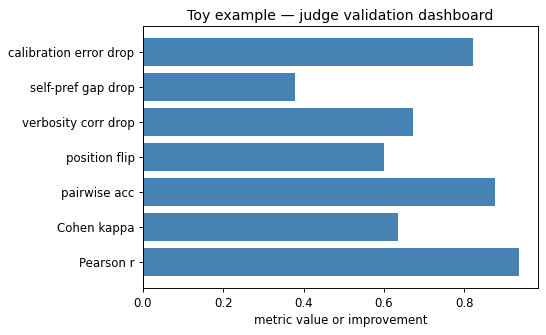

In [52]:
summary_metrics = pd.DataFrame({
    "check": [
        "Pearson r",
        "Cohen kappa",
        "pairwise acc",
        "position flip",
        "verbosity corr drop",
        "self-pref gap drop",
        "calibration error drop",
    ],
    "value": [
        pearson_r,
        kappa,
        pairwise_accuracy,
        swap_flip_rate,
        abs(length_score_corr) - abs(corr_after_length_control),
        own_gap - ensemble_gap,
        raw_calibration_error - calibrated_error,
    ],
})

log("validation summary", "\n" + summary_metrics.round(3).to_string(index=False))
log("key takeaway", "validate against humans, detect bias, debias, then calibrate")
assert summary_metrics.loc[summary_metrics["check"] == "calibration error drop", "value"].iloc[0] > 0
assert summary_metrics.loc[summary_metrics["check"] == "verbosity corr drop", "value"].iloc[0] > 0

plt.barh(summary_metrics["check"], summary_metrics["value"], color="steelblue")
plt.axvline(0, color="black")
plt.xlabel("metric value or improvement")
plt.title("Toy example — judge validation dashboard")
plt.show()

## Recap — M22 checklist

- **LLM-as-judge** = use a model to score or rank outputs, but in this notebook we simulated it offline.
- **Rubric** = criteria + anchored scale; anchors make scoring more consistent.
- **Inter-rater agreement** = compare judge to humans with Pearson/Spearman correlation, Cohen's kappa,
  and pairwise-preference accuracy.
- **Position bias** = first answer wins too often; detect by swapping order and fix by swap-and-average.
- **Verbosity bias** = longer answers score higher; detect length/score correlation and control for length.
- **Self-preference bias** = judge favors its own model family; mitigate with independent or ensemble judges.
- **Calibration** = judge score X should mean true quality X; fit a mapping and verify calibration error drops.

**Final takeaway:** never trust a judge you have not validated against humans, stress-tested for bias,
de-biased where possible, and calibrated.